## Plot noise in face data to see if denoising will be needed. We want to see if H matrix == identity


In [24]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [25]:
def get_bounding_box(filename):
    with open(filename) as f:
        data = f.readlines()

    combined = ' '.join(data)
    start = combined.index("{") + 3
    end = combined.index("}")
    points = [coord.split(" ") for coord in combined[start:end].strip().split("\n ")]
    points = np.array(points).astype(float)

    max_coords = np.max(points, axis=0)
    min_coords = np.min(points, axis=0)
    x, y = min_coords
    w, h = max_coords - min_coords
    
    return x, y, w, h

In [26]:
def train_video_test(video_id):
    # Return x, y, w, h instead of print
    filename = f"data/{video_id}/annot"
    frames = sorted(os.listdir(filename))
    xywh_list = []
    for frame in frames:
        if frame.endswith(".pts"):
            file = filename + "/" + frame
            x, y, w, h = get_bounding_box(file)
            xywh_list.append([x, y, w, h])
    return np.array(xywh_list)

In [27]:
xywh_001 = train_video_test("407")

In [28]:
print(xywh_001)

[[542.434 134.267 117.516 114.59 ]
 [544.97  134.303 117.15  116.017]
 [547.213 134.502 117.093 115.385]
 ...
 [587.816 135.145 120.206 122.137]
 [583.457 133.807 120.785 122.223]
 [579.247 132.628 121.106 121.829]]


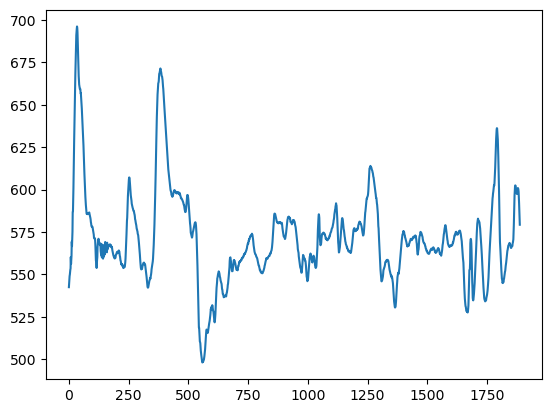

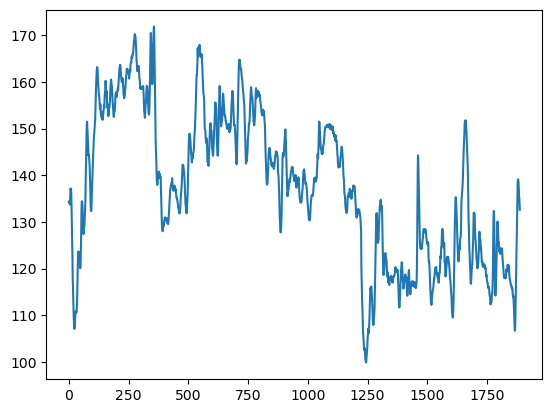

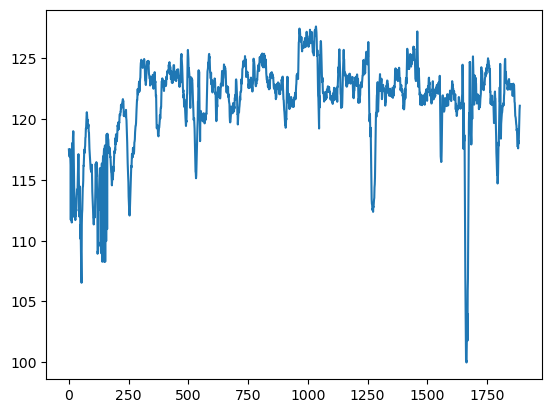

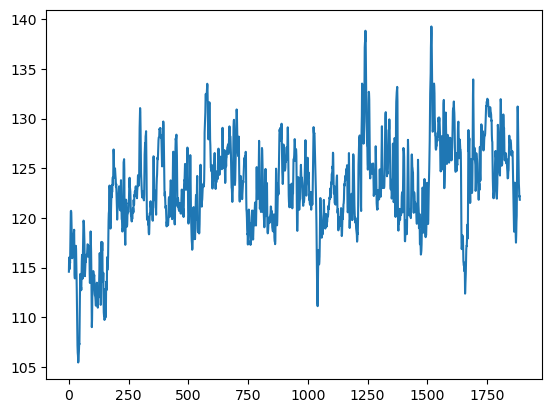

In [29]:
plt.plot(xywh_001[:, 0]) # x column
plt.show()

plt.plot(xywh_001[:, 1]) # y column
plt.show()

plt.plot(xywh_001[:, 2]) # w column
plt.show()

plt.plot(xywh_001[:, 3]) # h column
plt.show()


In [30]:
for i in range(4):
    print(np.var(np.diff(xywh_001[:, i])))

3.6726658662457474
1.358141996505811
1.0267026984940602
1.5188676790676414
